In [59]:
from sqlalchemy import create_engine

import pandas as pd

from db_config import CONN_STR

engine = create_engine(CONN_STR)

query = """
SELECT
    m.movie_id,
    m.title,
    m.release_date,
    m.year,
    m.genre,
    m.rating AS mpaa_rating,
    m.runtime_minutes,
    m.budget,
    m.production_company,
    m.country,
    
    d.name AS director_name,
    d.professions,

    fbo.worldwide,
    fbo.domestic,
    fbo.domestic_percent,
    fbo.foreign,
    fbo.foreign_percent,

    fmp.average_rating,
    fmp.number_of_votes,
    fmp.approval_index,
    fmp.production_budget,

    (SELECT STRING_AGG(s.name, ', ')
     FROM main.movie_stars ms
     JOIN main.dim_star s ON s.star_id = ms.star_id
     WHERE ms.movie_id = m.movie_id) AS stars,

    (SELECT STRING_AGG(w.name, ', ')
     FROM main.movie_writers mw
     JOIN main.dim_writer w ON w.writer_id = mw.writer_id
     WHERE mw.movie_id = m.movie_id) AS writers,

    foa.winner IS NOT NULL AS oscar_nominated,
    foa.winner AS oscar_winner

FROM main.dim_movie m
LEFT JOIN main.fact_box_office fbo ON fbo.movie_id = m.movie_id
LEFT JOIN main.fact_movie_performance fmp ON fmp.movie_id = m.movie_id
LEFT JOIN main.dim_director d ON d.director_id = fmp.director_id
LEFT JOIN main.fact_oscar_awards foa ON foa.movie_id = m.movie_id;
"""


df = pd.read_sql(query, engine)

print(df.shape)
print(df.head())
      



(9888, 25)
   movie_id                                              title release_date  \
0      1055                                        Topsy-Turvy   2000-02-11   
1      1033                                   The Time Machine   2002-03-08   
2       918                                       The Way Back   2011-01-21   
3       815                                            Ed Wood   1994-10-07   
4       565  The Lord of the Rings: The Fellowship of the Ring   2001-12-19   

   year      genre mpaa_rating  runtime_minutes      budget  \
0  1999  Biography           R            160.0         NaN   
1  2002     Action       PG-13             96.0  80000000.0   
2  2010  Adventure       PG-13            133.0  30000000.0   
3  1994  Biography           R            127.0  18000000.0   
4  2001     Action       PG-13            178.0  93000000.0   

    production_company         country  ...      foreign foreign_percent  \
0        Goldwyn Films  United Kingdom  ...          NaN   

Відсоток пропущених значень у кожному стовпці:

oscar_winner          67.131877
domestic              62.934871
foreign_percent       62.934871
foreign               62.934871
domestic_percent      62.934871
worldwide             62.934871
professions           49.696602
director_name         49.625809
production_budget     46.096278
average_rating        46.096278
number_of_votes       46.096278
approval_index        46.096278
budget                23.230178
mpaa_rating            0.778722
production_company     0.151699
runtime_minutes        0.020227
writers                0.020227
country                0.010113
stars                  0.010113
dtype: float64

Опис числових змінних:

          movie_id         year  runtime_minutes        budget     worldwide  \
count  9888.000000  9888.000000      9886.000000  7.591000e+03  3.665000e+03   
mean   3820.730178  2000.570995       112.391564  3.919896e+07  2.069636e+08   
std    2194.254561    11.231693        22.366143  4.420766e+07  

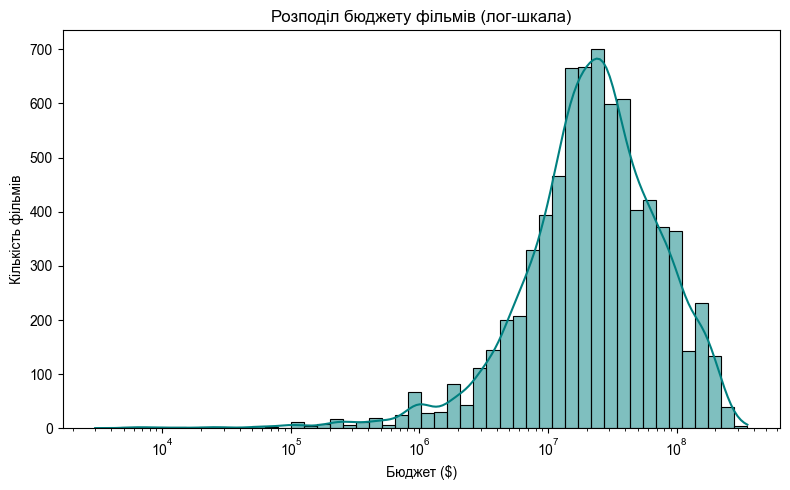

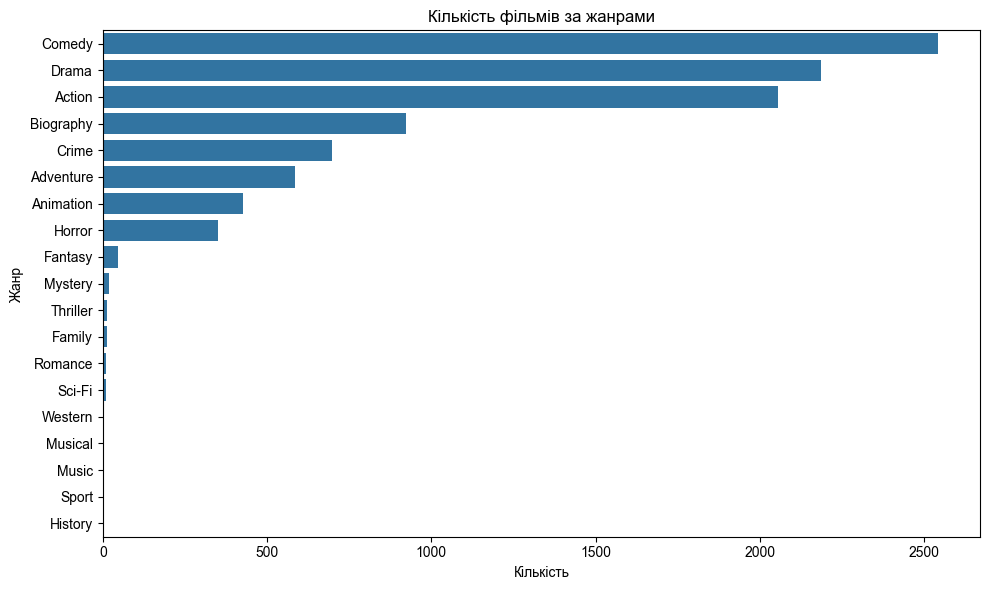

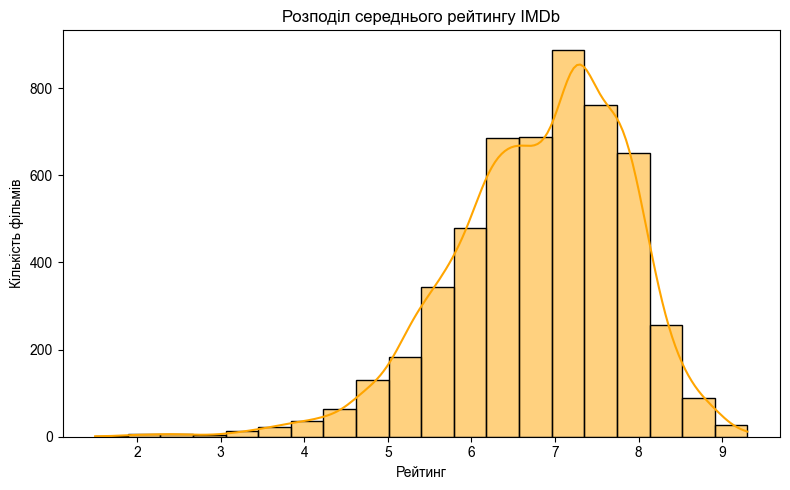

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Оцінка пропущених значень
missing = df.isnull().mean().sort_values(ascending=False) * 100
print("Відсоток пропущених значень у кожному стовпці:\n")
print(missing[missing > 0])

# 2. Загальний опис числових змінних
print("\nОпис числових змінних:\n")
print(df.describe())

# 3. Унікальні значення категоріальних змінних
print("\nКатегоріальні ознаки:\n")
categoricals = ['genre', 'mpaa_rating', 'country', 'production_company', 'director_name']
for col in categoricals:
    print(f"{col}: {df[col].nunique()} унікальних")

# 4. Розподіл бюджету (з лог-шкалою)
plt.figure(figsize=(8, 5))
sns.histplot(df['budget'].dropna(), bins=50, log_scale=(True, False), kde=True, color='teal')
plt.title('Розподіл бюджету фільмів (лог-шкала)')
plt.xlabel('Бюджет ($)')
plt.ylabel('Кількість фільмів')
plt.tight_layout()
plt.show()

# 5. Розподіл жанрів
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='genre', order=df['genre'].value_counts().index)
plt.title('Кількість фільмів за жанрами')
plt.xlabel('Кількість')
plt.ylabel('Жанр')
plt.tight_layout()
plt.show()

# 6. Рейтинг IMDb
plt.figure(figsize=(8, 5))
sns.histplot(df['average_rating'].dropna(), bins=20, kde=True, color='orange')
plt.title('Розподіл середнього рейтингу IMDb')
plt.xlabel('Рейтинг')
plt.ylabel('Кількість фільмів')
plt.tight_layout()
plt.show()


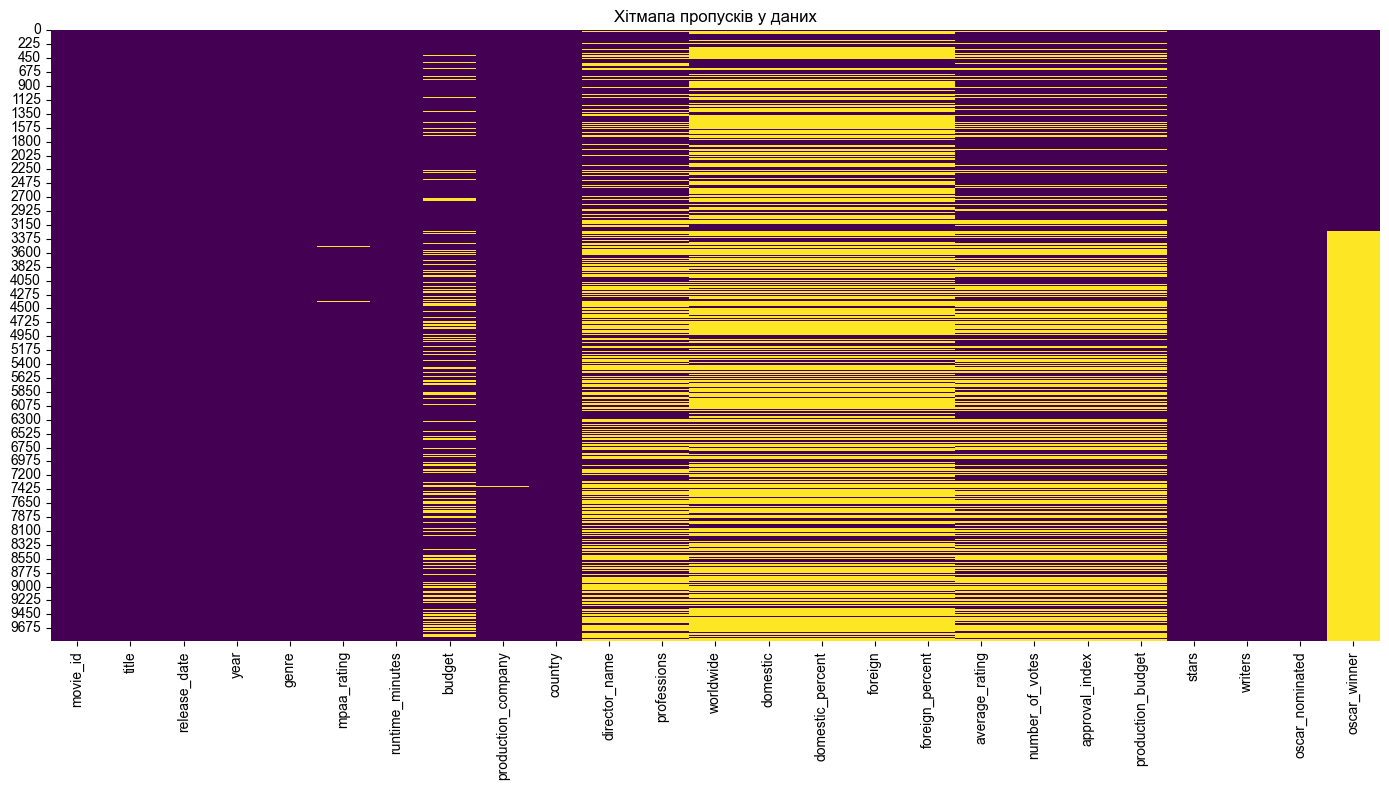

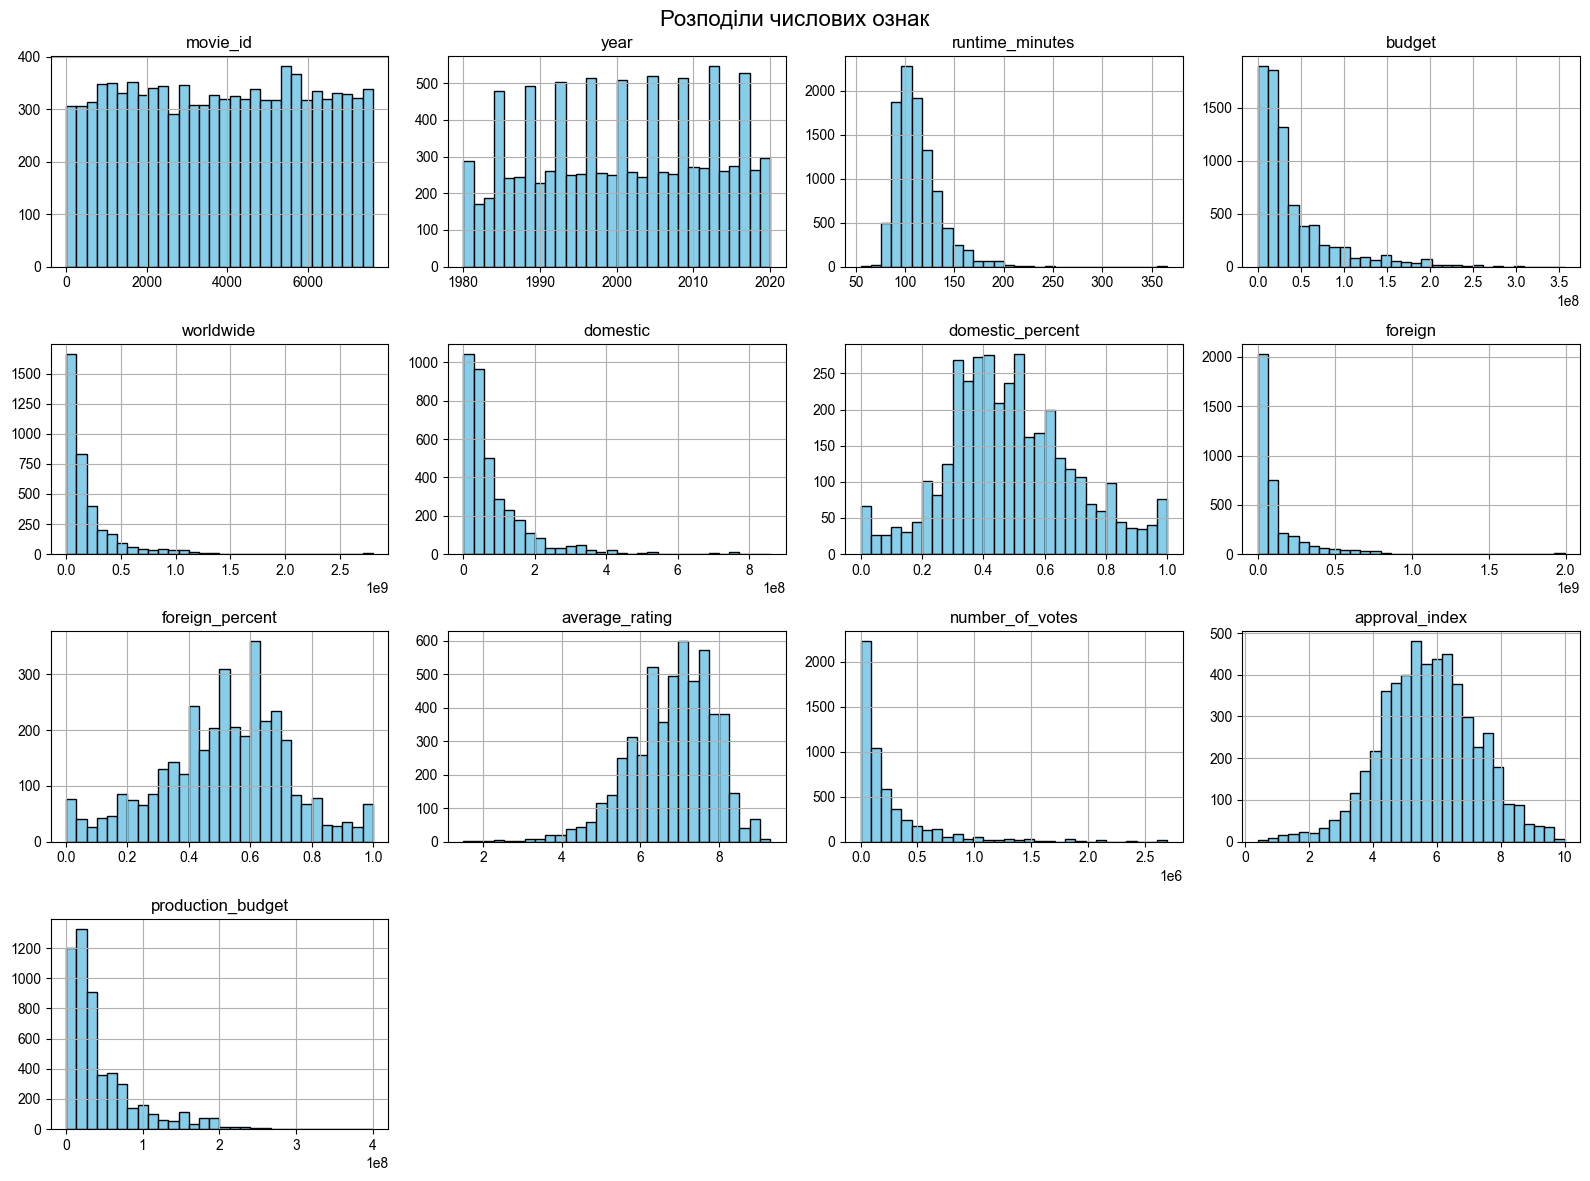

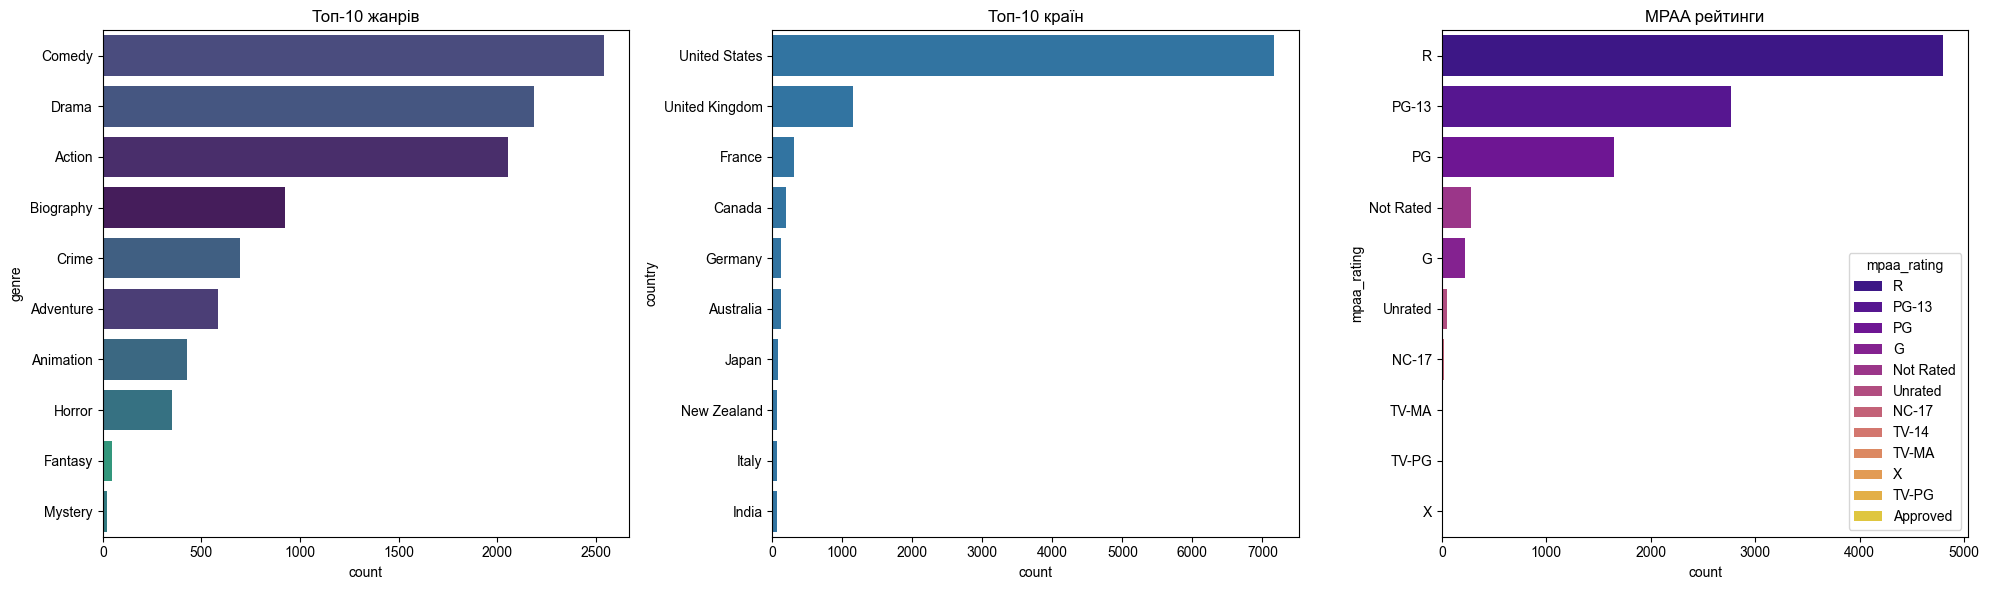

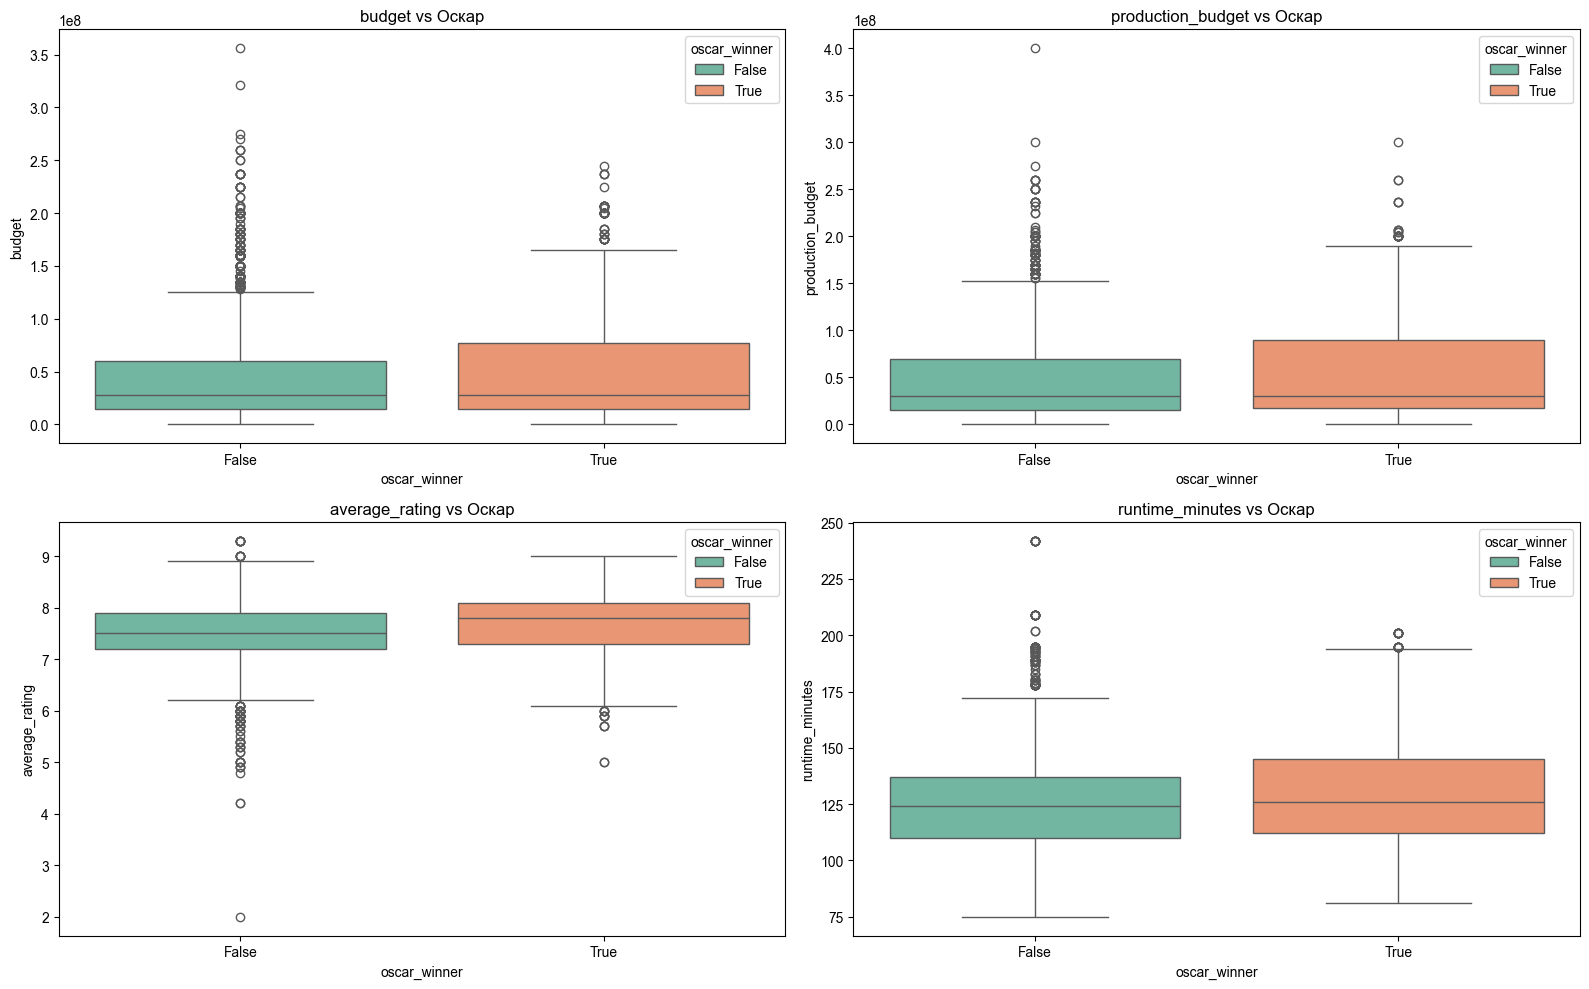

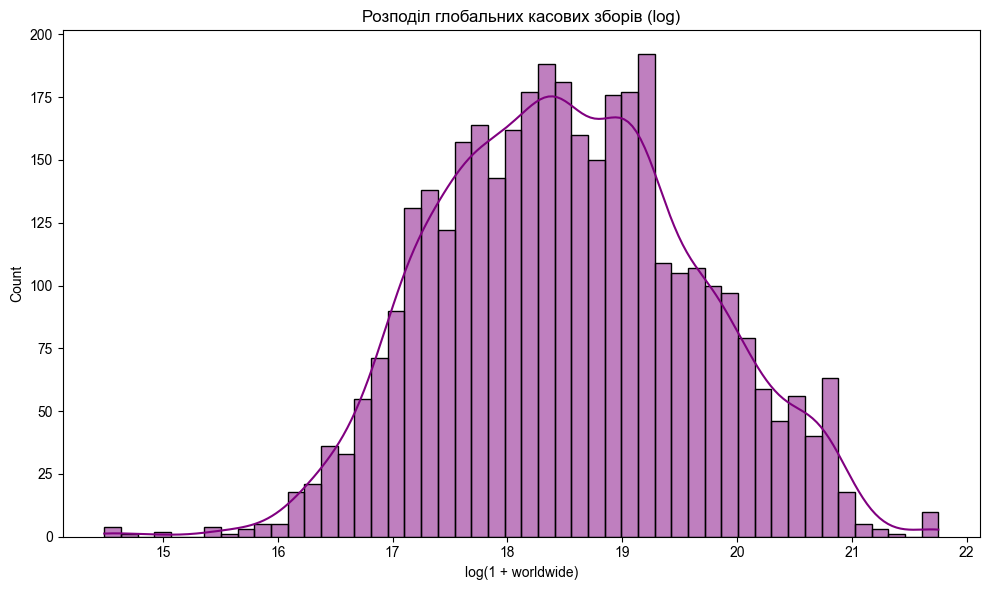

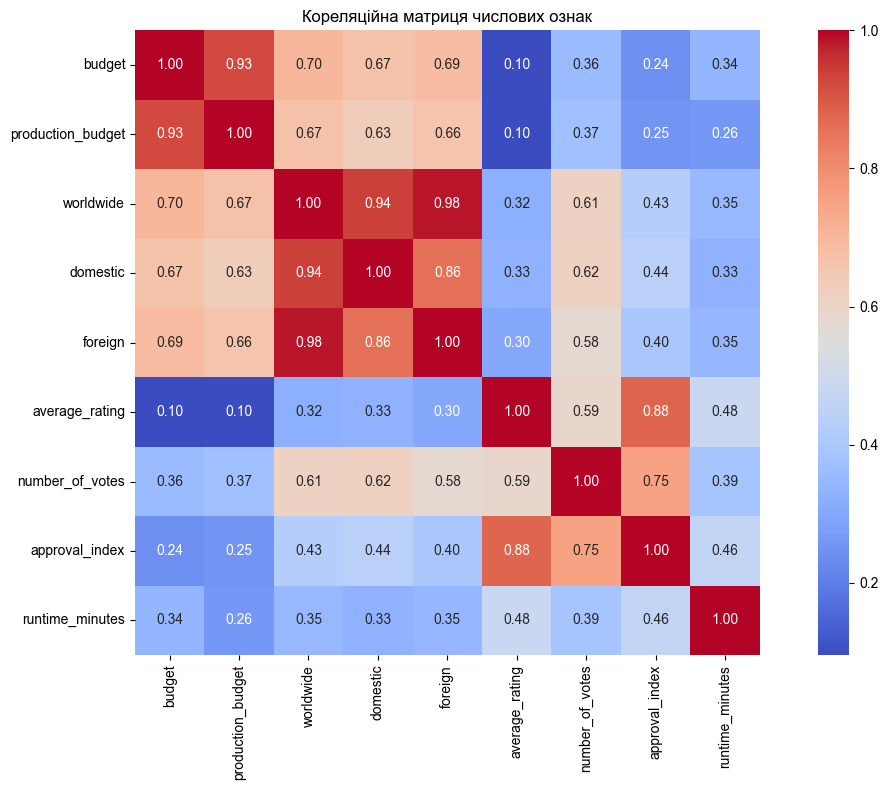

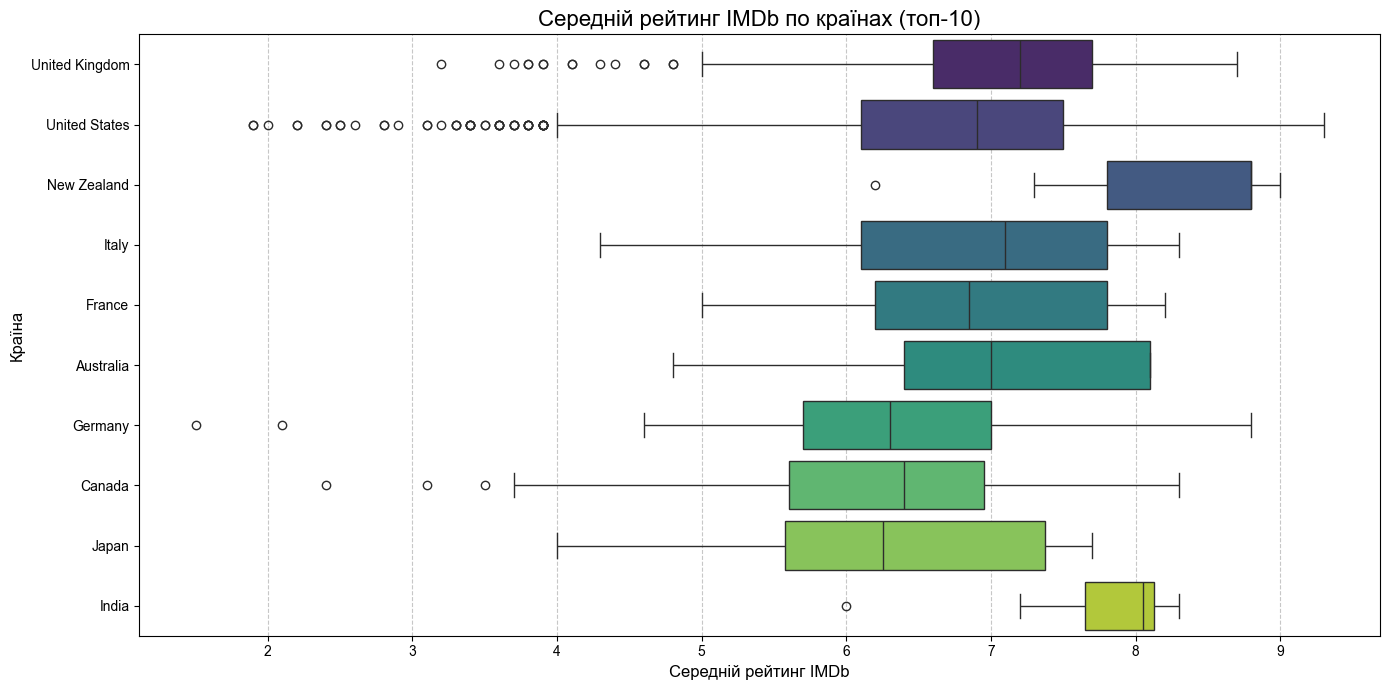

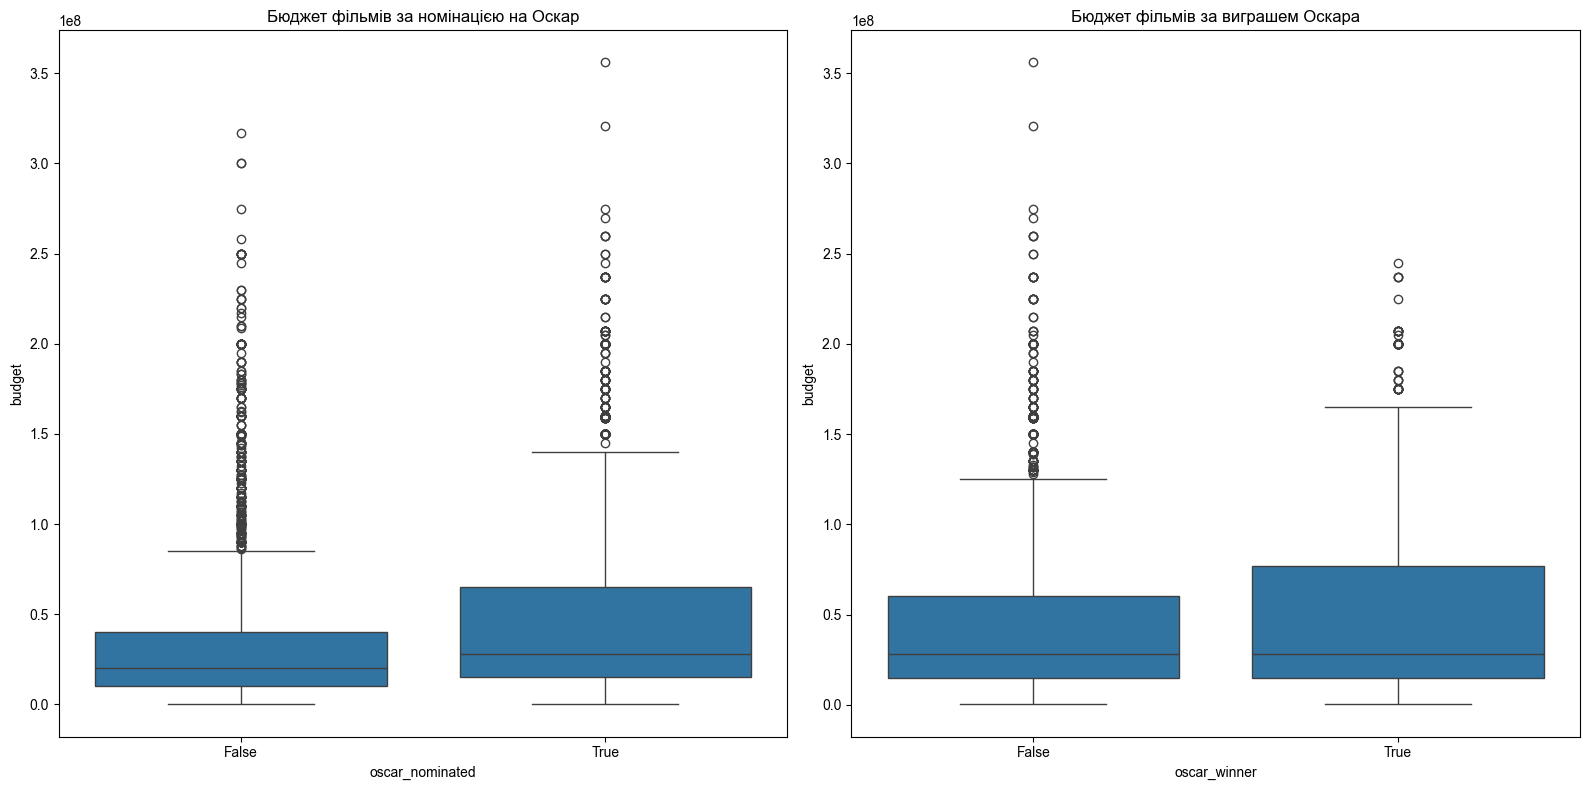

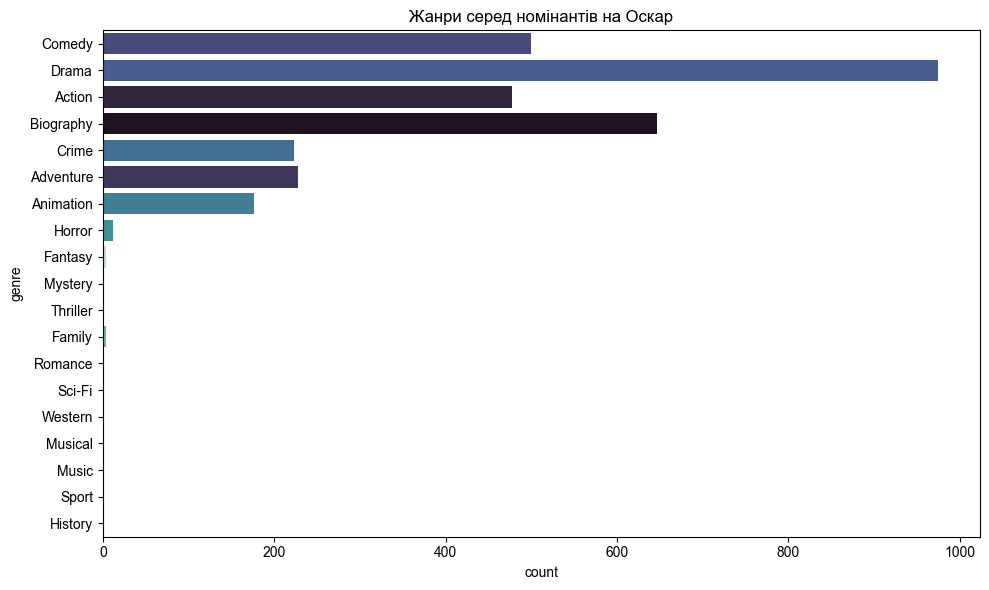

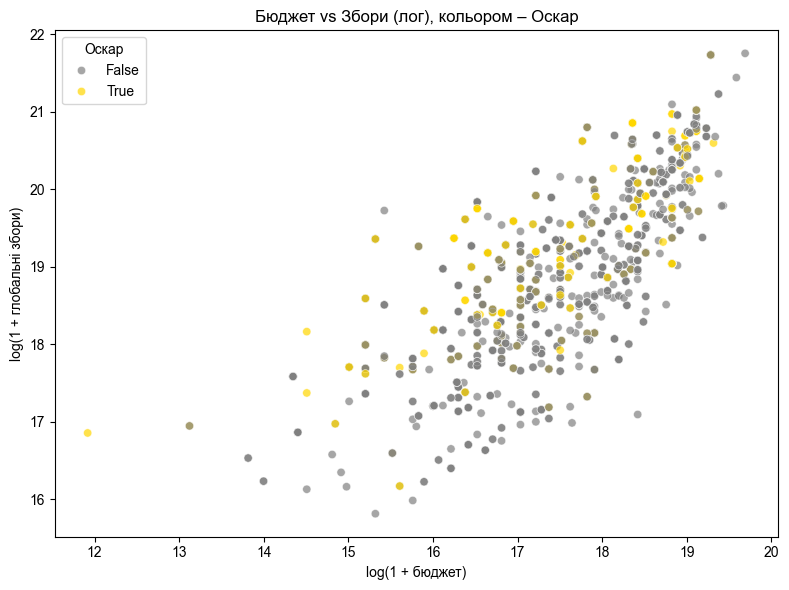

In [61]:
import matplotlib.pyplot as plt

import seaborn as sns

import numpy as np



# 1. Heatmap пропусків

plt.figure(figsize=(14, 8))

sns.heatmap(df.isnull(), cbar=False, cmap="viridis")

plt.title('Хітмапа пропусків у даних')

plt.tight_layout()

plt.show()



# 2. Розподіли числових змінних

numeric_cols = df.select_dtypes(include=[np.number]).columns

df[numeric_cols].hist(bins=30, figsize=(16, 12), color='skyblue', edgecolor='black')

plt.suptitle("Розподіли числових ознак", fontsize=16)

plt.tight_layout()

plt.show()



# 3. Топ-10 жанрів, країн, рейтингів MPAA

fig, axes = plt.subplots(1, 3, figsize=(20, 6))



sns.countplot(data=df, y='genre', order=df['genre'].value_counts().head(10).index, ax=axes[0], palette='viridis', hue='genre')

axes[0].set_title('Топ-10 жанрів')



sns.countplot(data=df, y='country', order=df['country'].value_counts().head(10).index, ax=axes[1])

axes[1].set_title('Топ-10 країн')



sns.countplot(data=df, y='mpaa_rating', order=df['mpaa_rating'].value_counts().head(10).index, ax=axes[2], palette='plasma', hue='mpaa_rating')

axes[2].set_title('MPAA рейтинги')



plt.tight_layout()

plt.show()



# 4. Boxplot — числові ознаки по Оскару

features = ['budget', 'production_budget', 'average_rating', 'runtime_minutes']

plt.figure(figsize=(16, 10))

for i, col in enumerate(features):

    plt.subplot(2, 2, i+1)
    sns.boxplot(data=df[df['oscar_winner'].notnull()], x='oscar_winner', y=col, palette='Set2', hue='oscar_winner')
    plt.title(f'{col} vs Оскар')
    
plt.tight_layout()
plt.show()





import numpy as np



# 1. Розподіли зборів (log-scale)

plt.figure(figsize=(10, 6))

sns.histplot(np.log1p(df['worldwide'].dropna()), bins=50, kde=True, color='purple')

plt.title('Розподіл глобальних касових зборів (log)')

plt.xlabel('log(1 + worldwide)')

plt.tight_layout()

plt.show()



# 2. Кореляційна матриця

plt.figure(figsize=(12, 8))

corr = df[['budget', 'production_budget', 'worldwide', 'domestic', 'foreign',

'average_rating', 'number_of_votes', 'approval_index', 'runtime_minutes']].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)

plt.title('Кореляційна матриця числових ознак')

plt.tight_layout()

plt.show()



# 3. Середній рейтинг по країнах (топ-10)

plt.figure(figsize=(14, 7))

# Define top_countries based on the count of movies in each country

top_countries = df['country'].value_counts().head(10).index



sns.boxplot(data=df[df['country'].isin(top_countries)],

x='average_rating', y='country', palette='viridis', hue='country')

plt.title('Середній рейтинг IMDb по країнах (топ-10)', fontsize=16)

plt.xlabel('Середній рейтинг IMDb', fontsize=12)

plt.ylabel('Країна', fontsize=12)

plt.xticks(fontsize=10)

plt.yticks(fontsize=10)

plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()







# 4. Бюджет фільмів за оскар-номінацією/виграшем

fig, axes = plt.subplots(1, 2, figsize=(16, 8)) # Increased figure size

sns.boxplot(data=df[df['oscar_nominated'].notnull()], x='oscar_nominated', y='budget', ax=axes[0])

axes[0].set_title('Бюджет фільмів за номінацією на Оскар')

sns.boxplot(data=df[df['oscar_winner'].notnull()], x='oscar_winner', y='budget', ax=axes[1])

axes[1].set_title('Бюджет фільмів за виграшем Оскара')



plt.tight_layout()

plt.show()



# 5. Жанри серед переможців/номінантів

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df[(df['oscar_nominated'].notnull()) & (df['oscar_nominated'] == True)],
    y='genre',
    order=df['genre'].value_counts().index,
    palette='mako',
    hue='genre'
)

plt.title('Жанри серед номінантів на Оскар')
plt.tight_layout()
plt.show()



# 6. Бюджет vs збори

plt.figure(figsize=(8, 6))





sns.scatterplot(
    data=df[(df['budget'].notnull()) & (df['worldwide'].notnull()) & (df['oscar_winner'].notnull())],
    x=np.log1p(df.loc[df['budget'].notnull(), 'budget']),
    y=np.log1p(df.loc[df['worldwide'].notnull(), 'worldwide']),
    hue='oscar_winner',
    alpha=0.7,
    palette={True: 'gold', False: 'gray'}
)

plt.xlabel('log(1 + бюджет)')
plt.ylabel('log(1 + глобальні збори)')
plt.title('Бюджет vs Збори (лог), кольором – Оскар')
plt.legend(title="Оскар")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Припустимо, ваш DataFrame називається df
# Переконайтеся, що ви завантажили свої дані в df

# 1. Розділення вибірки
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

print(f"Розмір тренувальної вибірки: {train_df.shape}")
print(f"Розмір тестової вибірки: {test_df.shape}")

# 2. Видалення стовпця 'professions'
train_df = train_df.drop(columns=['professions', 'domestic_percent', 'foreign_percent'])
test_df = test_df.drop(columns=['professions', 'domestic_percent', 'foreign_percent'])



# 3. Обробка числових стовпців у тренувальній вибірці
numeric_cols_to_fill = ['budget', 'production_budget', 'worldwide', 'domestic', 'foreign',
                       'average_rating', 'number_of_votes', 'approval_index', 'runtime_minutes']
medians = train_df[numeric_cols_to_fill].median()

# Заповнення пропусків медіанами в обох вибірках
train_df[numeric_cols_to_fill] = train_df[numeric_cols_to_fill].fillna(medians)
test_df[numeric_cols_to_fill] = test_df[numeric_cols_to_fill].fillna(medians)

# Створення індикаторних ознак для пропущених значень (наприклад, для бюджету та світових зборів)
train_df['budget_missing'] = train_df['budget'].isnull().astype(int)
test_df['budget_missing'] = test_df['budget'].isnull().astype(int)

train_df['worldwide_missing'] = train_df['worldwide'].isnull().astype(int)
test_df['worldwide_missing'] = test_df['worldwide'].isnull().astype(int)

train_df['average_rating_missing'] = train_df['average_rating'].isnull().astype(int)
test_df['average_rating_missing'] = test_df['average_rating'].isnull().astype(int)

# 4. Обробка категоріальних стовпців
categorical_cols_to_fill = ['mpaa_rating', 'production_company', 'director_name', 'country', 'stars', 'writers']
unknown_value = 'Unknown'
train_df[categorical_cols_to_fill] = train_df[categorical_cols_to_fill].fillna(unknown_value)
test_df[categorical_cols_to_fill] = test_df[categorical_cols_to_fill].fillna(unknown_value)

# Виведемо кількість пропусків після обробки для перевірки
print("\nКількість пропусків у тренувальній вибірці після обробки:")
print(train_df.isnull().sum().sort_values(ascending=False).head())

print("\nКількість пропусків у тестовій вибірці після обробки:")
print(test_df.isnull().sum().sort_values(ascending=False).head())

# Тепер train_df та test_df є обробленими версіями ваших даних без стовпця 'professions'.
# Надайте мені результати виконання цього коду.

Розмір тренувальної вибірки: (7910, 25)
Розмір тестової вибірки: (1978, 25)

Кількість пропусків у тренувальній вибірці після обробки:
oscar_winner         5315
domestic_percent     4979
foreign_percent      4979
foreign                 0
worldwide_missing       0
dtype: int64

Кількість пропусків у тестовій вибірці після обробки:
oscar_winner         1323
domestic_percent     1244
foreign_percent      1244
foreign                 0
worldwide_missing       0
dtype: int64


In [63]:
genre_dummies_train = pd.get_dummies(train_df['genre'], prefix='genre')
genre_dummies_test = pd.get_dummies(test_df['genre'], prefix='genre')
train_df = pd.concat([train_df, genre_dummies_train], axis=1)
test_df = pd.concat([test_df, genre_dummies_test], axis=1)

mpaa_rating_dummies_train = pd.get_dummies(train_df['mpaa_rating'], prefix='mpaa')
mpaa_rating_dummies_test = pd.get_dummies(test_df['mpaa_rating'], prefix='mpaa')
train_df = pd.concat([train_df, mpaa_rating_dummies_train], axis=1)
test_df = pd.concat([test_df, mpaa_rating_dummies_test], axis=1)

# Видаліть оригінальні стовпці після кодування
train_df = train_df.drop(columns=['genre', 'mpaa_rating'])
test_df = test_df.drop(columns=['genre', 'mpaa_rating'])

In [64]:
top_countries = train_df['country'].value_counts().nlargest(10).index
train_df['country_encoded'] = train_df['country'].apply(lambda x: x if x in top_countries else 'Other_Country')
test_df['country_encoded'] = test_df['country'].apply(lambda x: x if x in top_countries else 'Other_Country')

country_dummies_train = pd.get_dummies(train_df['country_encoded'], prefix='country')
country_dummies_test = pd.get_dummies(test_df['country_encoded'], prefix='country')
train_df = pd.concat([train_df, country_dummies_train], axis=1)
test_df = pd.concat([test_df, country_dummies_test], axis=1)

train_df = train_df.drop(columns=['country', 'country_encoded'])
test_df = test_df.drop(columns=['country', 'country_encoded'])

In [65]:
freq_map_company = train_df['production_company'].value_counts(normalize=True).to_dict()
train_df['production_company_freq'] = train_df['production_company'].map(freq_map_company).fillna(0)
test_df['production_company_freq'] = test_df['production_company'].map(freq_map_company).fillna(0) # Використовуємо мапінг з тренувальної!

# Можна також створити топ-N бінарні ознаки для найчастіших
top_companies = train_df['production_company'].value_counts().nlargest(20).index
for company in top_companies:
    train_df[f'company_{company.replace(" ", "_").replace(".", "")}'] = (train_df['production_company'] == company).astype(int)
    test_df[f'company_{company.replace(" ", "_").replace(".", "")}'] = (test_df['production_company'] == company).astype(int)

train_df = train_df.drop(columns=['production_company'])
test_df = test_df.drop(columns=['production_company'])

In [66]:
# Переконайтеся, що release_date є datetime об'єктом
train_df['release_date'] = pd.to_datetime(train_df['release_date'])
test_df['release_date'] = pd.to_datetime(test_df['release_date'])

# Рік вже є (стовпець 'year'), але можна перевірити/синхронізувати
train_df['release_year'] = train_df['release_date'].dt.year
test_df['release_year'] = test_df['release_date'].dt.year

train_df['release_month'] = train_df['release_date'].dt.month
test_df['release_month'] = test_df['release_date'].dt.month

train_df['release_dayofweek'] = train_df['release_date'].dt.dayofweek # 0 = Понеділок, 6 = Неділя
test_df['release_dayofweek'] = test_df['release_date'].dt.dayofweek

# Створення ознаки "сезон"
def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else: return 'Autumn'
train_df['season'] = train_df['release_month'].apply(get_season)
test_df['season'] = test_df['release_month'].apply(get_season)
season_dummies_train = pd.get_dummies(train_df['season'], prefix='season')
season_dummies_test = pd.get_dummies(test_df['season'], prefix='season')
train_df = pd.concat([train_df, season_dummies_train], axis=1)
test_df = pd.concat([test_df, season_dummies_test], axis=1)
train_df = train_df.drop(columns=['season'])
test_df = test_df.drop(columns=['season'])

# Створення ознаки "десятиліття"
train_df['decade'] = (train_df['release_year'] // 10) * 10
test_df['decade'] = (test_df['release_year'] // 10) * 10
decade_dummies_train = pd.get_dummies(train_df['decade'], prefix='decade')
decade_dummies_test = pd.get_dummies(test_df['decade'], prefix='decade')
train_df = pd.concat([train_df, decade_dummies_train], axis=1)
test_df = pd.concat([test_df, decade_dummies_test], axis=1)
train_df = train_df.drop(columns=['decade'])
test_df = test_df.drop(columns=['decade'])

# Видаліть release_date після вилучення всіх необхідних компонентів
train_df = train_df.drop(columns=['release_date'])
test_df = test_df.drop(columns=['release_date'])

In [67]:
# Функція для обробки списків імен
def extract_names(names_str):
    if pd.isna(names_str) or names_str == 'Unknown':
        return []
    return [name.strip() for name in names_str.split(',')]

train_df['stars_list'] = train_df['stars'].apply(extract_names)
test_df['stars_list'] = test_df['stars'].apply(extract_names)
train_df['writers_list'] = train_df['writers'].apply(extract_names)
test_df['writers_list'] = test_df['writers'].apply(extract_names)

# Кількість зірок/сценаристів
train_df['num_stars'] = train_df['stars_list'].apply(len)
test_df['num_stars'] = test_df['stars_list'].apply(len)
train_df['num_writers'] = train_df['writers_list'].apply(len)
test_df['num_writers'] = test_df['writers_list'].apply(len)

# Топ-N зірок (визначаємо на тренувальній вибірці)
from collections import Counter
all_stars_train = [star for sublist in train_df['stars_list'] for star in sublist]
top_n_stars = [star for star, count in Counter(all_stars_train).most_common(50)] # Наприклад, топ-50

for star in top_n_stars:
    star_col_name = f'star_{star.replace(" ", "_").replace(".", "")}'
    train_df[star_col_name] = train_df['stars_list'].apply(lambda x: int(star in x))
    test_df[star_col_name] = test_df['stars_list'].apply(lambda x: int(star in x))

# Аналогічно для Топ-N сценаристів
all_writers_train = [writer for sublist in train_df['writers_list'] for writer in sublist]
top_n_writers = [writer for writer, count in Counter(all_writers_train).most_common(30)] # Наприклад, топ-30

for writer in top_n_writers:
    writer_col_name = f'writer_{writer.replace(" ", "_").replace(".", "")}'
    train_df[writer_col_name] = train_df['writers_list'].apply(lambda x: int(writer in x))
    test_df[writer_col_name] = test_df['writers_list'].apply(lambda x: int(writer in x))

# Видаліть проміжні стовпці та оригінальні текстові
train_df = train_df.drop(columns=['stars', 'writers', 'stars_list', 'writers_list'])
test_df = test_df.drop(columns=['stars', 'writers', 'stars_list', 'writers_list'])

In [69]:
# 5. Цільові змінні (oscar_nominated, oscar_winner):

# Для oscar_nominated:
# SQL запит 'foa.winner IS NOT NULL' мав би створити булевий стовпець (True/False).
# Але якщо були повні пропуски записів з fact_oscar_awards, могли з'явитися NaN.
# Заповнюємо можливі NaN значення як False (не номінувався).
train_df['oscar_nominated'] = train_df['oscar_nominated'].fillna(False)
test_df['oscar_nominated'] = test_df['oscar_nominated'].fillna(False)
# Тепер конвертуємо в int (0 або 1)
train_df['oscar_nominated'] = train_df['oscar_nominated'].astype(int)
test_df['oscar_nominated'] = test_df['oscar_nominated'].astype(int)

# Для oscar_winner:
# Ви вказали, що відсутнє значення означає "не номінувався" (і, відповідно, не виграв).
# Заповнюємо NaN значення як False.
train_df['oscar_winner'] = train_df['oscar_winner'].fillna(False)
test_df['oscar_winner'] = test_df['oscar_winner'].fillna(False)
# Тепер конвертуємо в int (0 або 1)
train_df['oscar_winner'] = train_df['oscar_winner'].astype(int)
test_df['oscar_winner'] = test_df['oscar_winner'].astype(int)

print("Перевірка типів даних для oscar_nominated та oscar_winner в train_df:")
print(train_df[['oscar_nominated', 'oscar_winner']].dtypes)
print("\nПеревірка унікальних значень для oscar_nominated та oscar_winner в train_df:")
print("oscar_nominated unique:", train_df['oscar_nominated'].unique())
print("oscar_winner unique:", train_df['oscar_winner'].unique())

Перевірка типів даних для oscar_nominated та oscar_winner в train_df:
oscar_nominated    int64
oscar_winner       int64
dtype: object

Перевірка унікальних значень для oscar_nominated та oscar_winner в train_df:
oscar_nominated unique: [0 1]
oscar_winner unique: [0 1]


/var/folders/n2/x50vbmb565bg112bmrww9vp40000gn/T/ipykernel_11996/116487642.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_df['oscar_winner'] = train_df['oscar_winner'].fillna(False)
/var/folders/n2/x50vbmb565bg112bmrww9vp40000gn/T/ipykernel_11996/116487642.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_df['oscar_winner'] = test_df['oscar_winner'].fillna(False)


In [70]:
import pandas as pd # Переконайтесь, що pandas імпортовано

# Припускаємо, що ваші датафрейми називаються train_df та test_df

print("--- Результати після обробки ознак ---")

print("\n1. Розміри датафреймів:")
print(f"Розмір тренувальної вибірки (train_df): {train_df.shape}")
print(f"Розмір тестової вибірки (test_df): {test_df.shape}")

print("\n2. Список стовпців у тренувальній вибірці (перші 30, якщо їх багато):")
print(train_df.columns.tolist()[:30]) # Показати перші 30 для оглядовості
if len(train_df.columns) > 30:
    print(f"...та ще {len(train_df.columns) - 30} стовпців.")


print("\n3. Перші 3 рядки тренувальної вибірки (транспоновано для кращої читабельності, якщо багато стовпців):")
if train_df.shape[1] > 15: # Якщо багато стовпців, транспонуємо
    print(train_df.head(3).T)
else:
    print(train_df.head(3))

print("\n4. Загальна кількість пропущених значень:")
print(f"Пропущено в train_df: {train_df.isnull().sum().sum()}")
print(f"Пропущено в test_df: {test_df.isnull().sum().sum()}")

print("\n5. Типи даних кількох ключових та новостворених стовпців (приклад):")
example_cols = ['budget', 'runtime_minutes', 'average_rating', 'worldwide',
                'release_year', 'release_month', 'num_stars', # Приклади кількісних/дат
                'oscar_nominated', 'oscar_winner'] # Цільові
# Додайте сюди назви кількох one-hot encoded стовпців, якщо вони є, наприклад:
# if 'genre_Action' in train_df.columns: example_cols.append('genre_Action')
# if 'country_USA' in train_df.columns: example_cols.append('country_USA')
# if 'season_Summer' in train_df.columns: example_cols.append('season_Summer')

# Фільтруємо example_cols, щоб залишити тільки ті, що реально є в train_df
actual_example_cols = [col for col in example_cols if col in train_df.columns]
if actual_example_cols:
    print(train_df[actual_example_cols].info())
else:
    print("Не знайдено прикладних стовпців для виводу типів даних. Перевірте назви.")

print("\n--- Кінець результатів ---")

--- Результати після обробки ознак ---

1. Розміри датафреймів:
Розмір тренувальної вибірки (train_df): (7910, 177)
Розмір тестової вибірки (test_df): (1978, 171)

2. Список стовпців у тренувальній вибірці (перші 30, якщо їх багато):
['movie_id', 'title', 'year', 'runtime_minutes', 'budget', 'director_name', 'worldwide', 'domestic', 'domestic_percent', 'foreign', 'foreign_percent', 'average_rating', 'number_of_votes', 'approval_index', 'production_budget', 'oscar_nominated', 'oscar_winner', 'budget_missing', 'worldwide_missing', 'average_rating_missing', 'genre_Action', 'genre_Adventure', 'genre_Animation', 'genre_Biography', 'genre_Comedy', 'genre_Crime', 'genre_Drama', 'genre_Family', 'genre_Fantasy', 'genre_Horror']
...та ще 147 стовпців.

3. Перші 3 рядки тренувальної вибірки (транспоновано для кращої читабельності, якщо багато стовпців):
                                       3328            2510              6867
movie_id                                786            2155        